# 01 · EDA — four datasets (Mercedes-only)

Goal: filter `merc.csv` (UK/GBP), `germany_dataset.csv` (EUR), `vehicles_craigslist.csv` (US/USD) and `cars-spec-dataset.csv` (spec enrichment) to Mercedes-Benz, profile each, and document the preprocessing each needs before they are pooled into one RM training set. **None of these are Malaysian prices** — they are foreign price levels FX-converted to RM, tagged with `source_market`.

In [ ]:
import sys, pathlib
for _c in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (_c / 'app').exists() and (_c / 'ml').exists():
        sys.path.insert(0, str(_c)); break
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from ml import ingest
sns.set_theme(); pd.set_option('display.max_columns', 60)

## merc.csv — UK (GBP)
Already all Mercedes; clean, no nulls; `model` has leading spaces + numeric-only classes (180/200/220/230); mileage is in **miles**.

In [ ]:
_root = _c
while not (_root / 'data' / 'raw').exists() and _root != _root.parent:
    _root = _root.parent
merc = pd.read_csv(_root / 'data' / 'raw' / 'merc.csv'); merc['model'] = merc['model'].str.strip()
print(merc.shape); display(merc.head())
print(merc.isna().sum().to_dict())
display(merc[['transmission','fuelType']].melt().groupby(['variable','value']).size())

(13119, 9)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,SLK,2005,5200,Automatic,63000,Petrol,325,32.1,1.8
1,S Class,2017,34948,Automatic,27000,Hybrid,20,61.4,2.1
2,SL CLASS,2016,49948,Automatic,6200,Petrol,555,28.0,5.5
3,G Class,2016,61948,Automatic,16000,Petrol,325,30.4,4.0
4,G Class,2016,73948,Automatic,4000,Petrol,325,30.1,4.0


{'model': 0, 'year': 0, 'price': 0, 'transmission': 0, 'mileage': 0, 'fuelType': 0, 'tax': 0, 'mpg': 0, 'engineSize': 0}


variable      value    
fuelType      Diesel       9187
              Hybrid        173
              Other           7
              Petrol       3752
transmission  Automatic    4825
              Manual       1444
              Other           2
              Semi-Auto    6848
dtype: int64

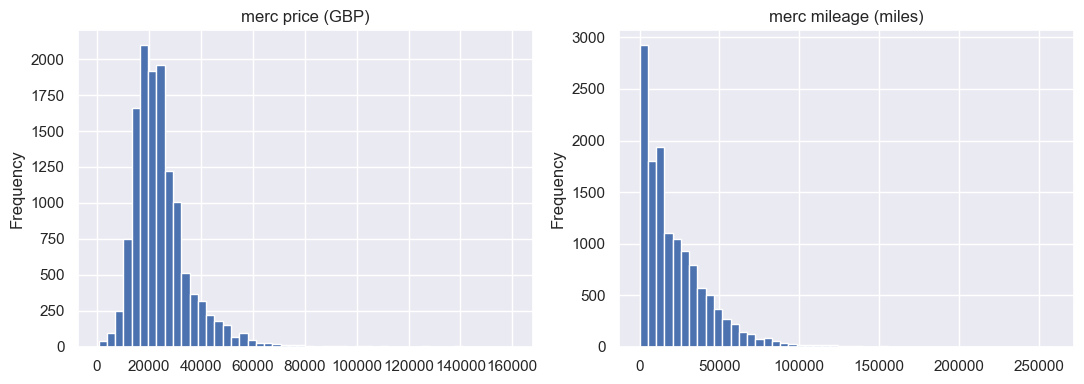

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(11,4))
merc['price'].plot.hist(bins=50, ax=ax[0], title='merc price (GBP)')
merc['mileage'].plot.hist(bins=50, ax=ax[1], title='merc mileage (miles)'); plt.tight_layout()

### merc.csv — model / year / transmission breakdown

In [ ]:
print('number of unique models:', merc['model'].nunique())
display(merc['model'].value_counts())

number of unique models: 27


model
C Class      3747
A Class      2561
E Class      1953
GLC Class     960
GLA Class     847
B Class       591
CL Class      511
GLE Class     461
SL CLASS      260
CLS Class     237
V Class       207
S Class       197
GL Class      121
SLK            95
CLA Class      86
X-CLASS        82
M Class        79
GLS Class      74
GLB Class      19
G Class        15
CLK             7
CLC Class       3
R Class         2
180             1
230             1
220             1
200             1
Name: count, dtype: int64

In [ ]:
year_counts = pd.crosstab(merc['model'], merc['year']).sort_index(axis=1)
display(year_counts)

year,1970,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
model,,,,,,,,,,,,,,,,,,,,,,,,,
180,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
200,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
220,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
230,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
A Class,0,0,0,0,0,0,0,1,0,0,1,4,0,0,1,4,2,80,124,149,407,466,339,745,238
B Class,0,0,0,0,0,0,0,0,0,1,0,2,1,2,3,3,6,20,28,24,43,83,40,296,39
C Class,0,0,0,0,0,0,2,0,2,1,3,6,7,7,9,9,24,63,133,303,524,635,360,1551,108
CL Class,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,8,34,72,93,96,40,140,26
CLA Class,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,4,7,24,21,3,12,12


In [ ]:
trans_counts = pd.crosstab(merc['model'], merc['transmission'])
trans_counts['total'] = trans_counts.sum(axis=1)
display(trans_counts.sort_values('total', ascending=False))

transmission,Automatic,Manual,Other,Semi-Auto,total
model,,,,,
C Class,1497,200,0,2050,3747
A Class,678,799,0,1084,2561
E Class,804,7,0,1142,1953
GLC Class,305,0,0,655,960
GLA Class,230,92,1,524,847
B Class,183,126,0,282,591
CL Class,121,99,0,291,511
GLE Class,155,0,0,306,461
SL CLASS,115,13,0,132,260


## germany_dataset.csv — Germany (EUR)
Multi-brand -> filter `brand`. Specific model names ('Mercedes-Benz E 220') carry a displacement-hinting badge; `fuel_type` has **leaked garbage** (dates/mileage strings); no engine-size column; mileage already km.

In [ ]:
ger = pd.read_csv(ingest.GERMANY_CSV)
mger = ger[ger['brand'].str.lower().str.contains('mercedes', na=False)]
print('mercedes rows:', mger.shape)
display(mger[['model','year','price_in_euro','transmission_type','fuel_type','mileage_in_km']].head())
print('fuel_type (dirty):', mger['fuel_type'].value_counts().head(8).to_dict())

## vehicles_craigslist.csv — US (USD)
Multi-brand -> filter `manufacturer`. Free-text lowercase model ('e320 cdi', 'ml350', 'benz'); price has 0 -> 3-billion outliers; odometer in **miles**; many nulls; no engine-size column.

In [ ]:
cl = pd.read_csv(ingest.CRAIGSLIST_CSV, low_memory=False)
mcl = cl[cl['manufacturer'].str.lower().str.contains('mercedes', na=False)]
print('mercedes rows:', mcl.shape)
display(mcl[['model','year','price','odometer','transmission','fuel']].head())
print('price describe:', mcl['price'].describe()[['min','50%','max']].to_dict())

## cars-spec-dataset.csv — spec enrichment source
Filter `Company`. ~2.4k Mercedes variants keyed by `Serie` (German) + `Production years`. Strong coverage of the specs we enrich with (parsing handled in `ml.ingest.clean_spec`).

In [ ]:
specs = ingest.clean_spec()
print('parsed Mercedes spec variants:', specs.shape)
cover = {c: f'{specs[c].notna().mean()*100:.0f}%' for c in ingest.ENRICH_NUM + ingest.ENRICH_CAT}
print('enriched-field coverage:', cover)
display(specs.head())

## Class-mapping feasibility (enrichment ceiling)
`ingest.canon_class` maps each source's model string to a canonical class. A row can only be spec-enriched if its class exists in the spec table.

In [ ]:
sc = set(specs['model_class'])
def cov(name, s):
    c = s.map(ingest.canon_class)
    print(f'{name:11s} parsed a class: {c.notna().mean()*100:5.1f}% | '
          f'class in spec: {c.isin(sc).mean()*100:5.1f}%')
cov('merc', merc['model']); cov('germany', mger['model']); cov('craigslist', mcl['model'])

## Preprocessing contract (per dataset)
- **merc (uk):** strip model -> `canon_class`; miles->km; GBP->RM (`fx_gbp_to_rm`); real `engineSize` kept; `source_market='uk'`. Drop numeric-only classes (unmapped).
- **germany:** filter brand; `canon_class`; km as-is; EUR->RM (`fx_eur_to_rm`); normalise dirty `fuel_type`/`transmission`; badge -> engine hint; enrich engine_size.
- **craigslist (us):** filter manufacturer; `canon_class`; miles->km; USD->RM (`fx_usd_to_rm`); drop price/odometer outliers; enrich engine_size.
- **cars-spec:** filter Company; parse displacement/torque/top-speed/accel/boot/gears/aspiration/brakes; build class x year lookup.

Shared pool filters: `1990 <= year <= 2026`, `price_rm in [3k, 2M]`, `mileage <= 500k km`, drop dupes. Then `battery_soh` / `trans_adapt_offset` are engineered (unchanged). All of this is implemented + tested in `ml.ingest`; `02_cleaning.ipynb` runs it.

> **Training-pool decision:** craigslist (US) is *explored here but excluded from the training pool* — its listings are the noisiest (validation MAPE ~49% vs UK 10% / germany 24%). `ml.ingest.build_pool` trains on UK + germany only.